<a href="https://colab.research.google.com/github/mnbatistapereira-ai/GS_SOLU-ES_EM_ENERGIAS_RENOV-VEIS_E_SUSTENT-VEIS/blob/main/GS_ENERGIAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Space Energy Monitor

In [40]:
#IMPORTAÇÃO DAS BIBLIOTECAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

In [41]:
#CONFIGURAÇÕES INICIAIS
np.random.seed(42)
random.seed(42)

TOTAL_REGISTROS = 200

In [42]:
#GERAÇÃO DOS DADOS DA MISSÃO
dados = []

tempo_inicial = datetime.now()

temperatura = 25
bateria = 100
sinal = 95

for i in range(TOTAL_REGISTROS):

    timestamp = tempo_inicial + timedelta(minutes=i)

    temperatura += random.uniform(-2, 2)
    temperatura = max(-10, min(85, temperatura))

    energia_solar = random.uniform(40, 100)

    consumo = random.uniform(20, 80)

    bateria += (energia_solar - consumo) * 0.05
    bateria = max(0, min(100, bateria))

    sinal += random.uniform(-5, 5)
    sinal = max(0, min(100, sinal))

    modulo_cientifico = random.choice([
        "ATIVO",
        "ATIVO",
        "ATIVO",
        "ATIVO",
        "FALHA"
    ])

    modulo_comunicacao = random.choice([
        "ATIVO",
        "ATIVO",
        "ATIVO",
        "FALHA"
    ])

    modulo_energia = random.choice([
        "ATIVO",
        "ATIVO",
        "ATIVO",
        "ATIVO",
        "ATIVO",
        "FALHA"
    ])

    dados.append([
        timestamp,
        round(temperatura, 2),
        round(energia_solar, 2),
        round(consumo, 2),
        round(bateria, 2),
        round(sinal, 2),
        modulo_cientifico,
        modulo_comunicacao,
        modulo_energia
    ])

In [43]:
#DATAFRAME
colunas = [
"Timestamp",
"Temperatura",
"Energia_Solar",
"Consumo",
"Bateria",
"Sinal",
"Modulo_Cientifico",
"Modulo_Comunicacao",
"Modulo_Energia"
]

df = pd.DataFrame(dados, columns=colunas)

df.head()

,Timestamp,Temperatura,Energia_Solar,Consumo,Bateria,Sinal,Modulo_Cientifico,Modulo_Comunicacao,Modulo_Energia
0,2026-06-09 15:58:24.609368,25.56,41.50,36.50,100.0,92.23,ATIVO,ATIVO,ATIVO
1,2026-06-09 15:59:24.609368,25.25,41.79,33.12,100.0,92.29,ATIVO,ATIVO,FALHA
2,2026-06-09 16:00:24.609368,25.84,72.70,33.23,100.0,93.18,ATIVO,ATIVO,FALHA
3,2026-06-09 16:01:24.609368,25.54,56.67,32.92,100.0,95.81,ATIVO,ATIVO,ATIVO
4,2026-06-09 16:02:24.609368,23.92,90.85,56.22,100.0,98.88,ATIVO,ATIVO,ATIVO


In [44]:
#CÁLCULO DE EFICIÊNCIA ENERGÉTICA
df["Eficiencia"] = (
df["Energia_Solar"] /
df["Consumo"]
)

In [45]:
#SISTEMA DE ALERTAS
alertas = []

for _, linha in df.iterrows():
    if linha["Bateria"] < 15:
        alertas.append("CRITICO")
    elif linha["Temperatura"] > 70:
        alertas.append("CRITICO")

    elif linha["Sinal"] < 20:
        alertas.append("CRITICO")

    elif linha["Bateria"] < 40:
        alertas.append("ATENCAO")

    elif linha["Temperatura"] > 55:
        alertas.append("ATENCAO")
    else:
        alertas.append("NORMAL")

df["Alerta"] = alertas

In [46]:
#SISTEMA ESPECIALISTA
acoes = []

for _, linha in df.iterrows():

    if linha["Bateria"] < 15:
        acao = "Ativar modo economico"

    elif linha["Temperatura"] > 70:
        acao = "Ativar resfriamento emergencial"

    elif linha["Sinal"] < 20:
        acao = "Reiniciar antena principal"

    elif linha["Bateria"] < 40:
        acao = "Reduzir consumo energetico"

    elif linha["Temperatura"] > 55:
        acao = "Monitorar sistema termico"

    else:
        acao = "Operacao normal"

    acoes.append(acao)

df["Acao_Automatica"] = acoes

In [47]:
#INDICE SAÚDE DA MISSÃO
indice_saude_missao = []

for _, linha in df.iterrows():

    score = 100

    score -= abs(linha["Temperatura"] - 25) * 0.5

    score -= (100 - linha["Bateria"]) * 0.2

    score -= (100 - linha["Sinal"]) * 0.1

    score -= abs(1 - linha["Eficiencia"]) * 10

    score = max(0, min(100, score))

    indice_saude_missao.append(round(score, 2))

df["Indice_Saude_Missao"] = indice_saude_missao

In [48]:
#RELATÓRIO GERAL
print("===== RELATORIO OPERACIONAL =====")

print()

print("Temperatura Media:",
round(df["Temperatura"].mean(),2),"°C")

print("Energia Solar Media:",
round(df["Energia_Solar"].mean(),2))

print("Consumo Medio:",
round(df["Consumo"].mean(),2))

print("Bateria Media:",
round(df["Bateria"].mean(),2),"%")

print("Sinal Medio:",
round(df["Sinal"].mean(),2),"%")

print("Eficiência Media:",
round(df["Eficiencia"].mean(),2))

print("Indice de Saude da Missao:",
round(df["Indice_Saude_Missao"].mean(),2))

print()

print("Alertas Criticos:",
len(df[df["Alerta"] == "CRITICO"]))

print("Alertas Atencao:",
len(df[df["Alerta"] == "ATENCAO"]))

===== RELATORIO OPERACIONAL =====

Temperatura Media: 25.34 °C
Energia Solar Media: 68.8
Consumo Medio: 48.46
Bateria Media: 99.78 %
Sinal Medio: 80.53 %
Eficiência Media: 1.62
Indice de Saude da Missao: 89.1

Alertas Criticos: 0
Alertas Atencao: 0


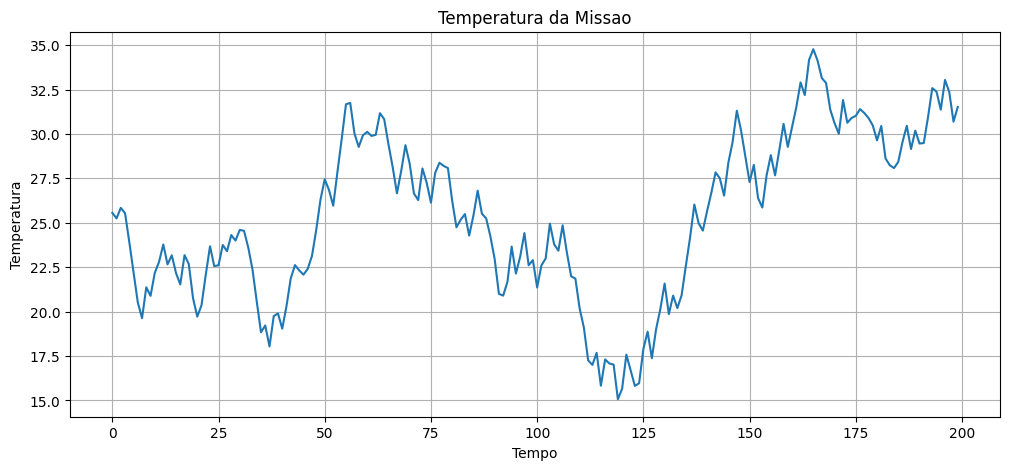

In [49]:
#GRÁFICO DA TEMPERATURA
plt.figure(figsize=(12,5))

plt.plot(df["Temperatura"])

plt.title("Temperatura da Missao")

plt.xlabel("Tempo")

plt.ylabel("Temperatura")

plt.grid()

plt.show()

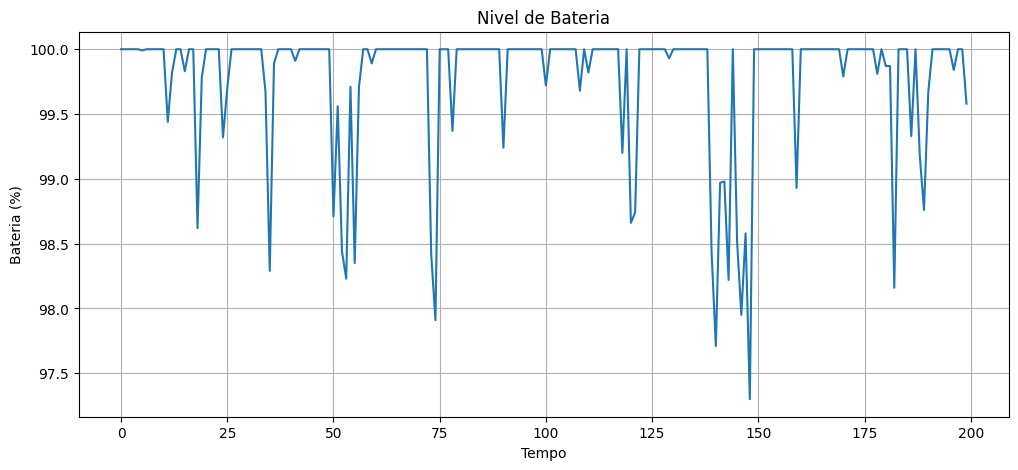

In [50]:
#GRÁFICO DA BATERIA
plt.figure(figsize=(12,5))

plt.plot(df["Bateria"])

plt.title("Nivel de Bateria")

plt.xlabel("Tempo")

plt.ylabel("Bateria (%)")

plt.grid()

plt.show()

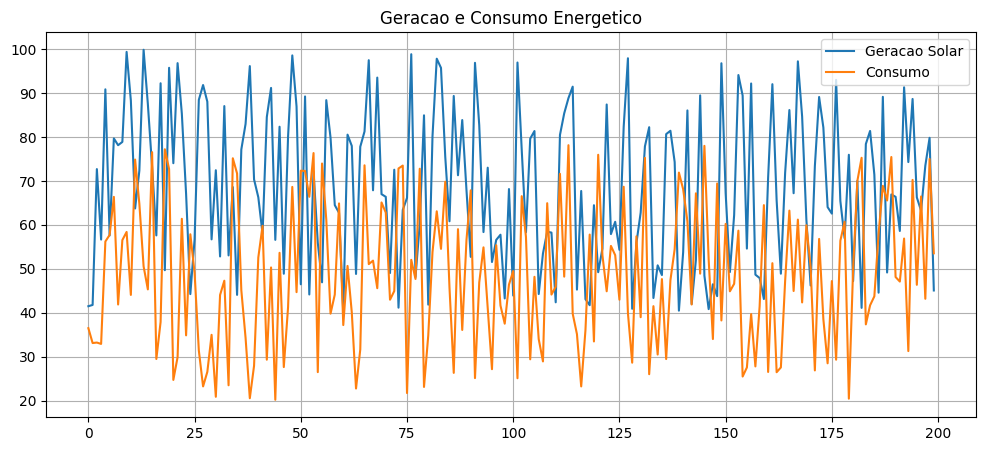

In [51]:
#GRÁFICO DE ENERGIA
plt.figure(figsize=(12,5))

plt.plot(df["Energia_Solar"],
label="Geracao Solar")

plt.plot(df["Consumo"],
label="Consumo")

plt.legend()

plt.title("Geracao e Consumo Energetico")

plt.grid()

plt.show()

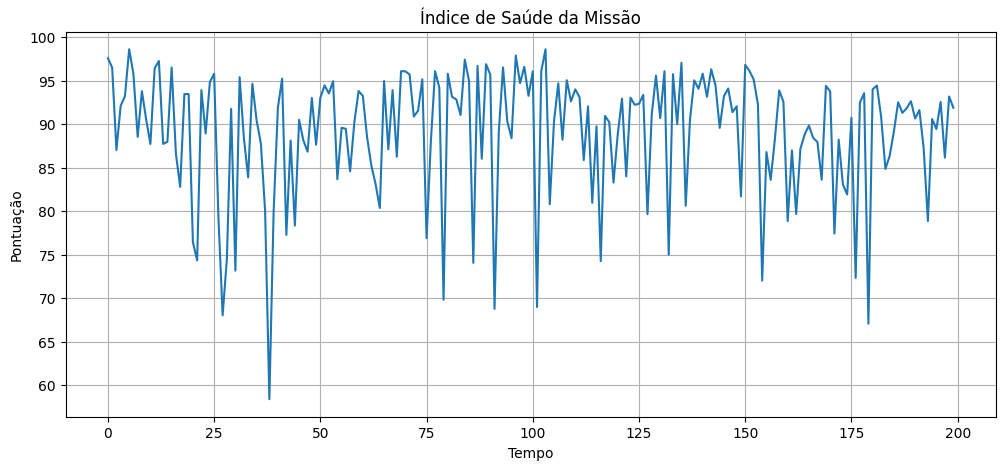

In [52]:
#GRÁFICO DO INDICE DE SAÚDE DA MISSÃO
plt.figure(figsize=(12,5))

plt.plot(df["Indice_Saude_Missao"])

plt.title("Índice de Saúde da Missão")

plt.xlabel("Tempo")

plt.ylabel("Pontuação")

plt.grid()

plt.show()

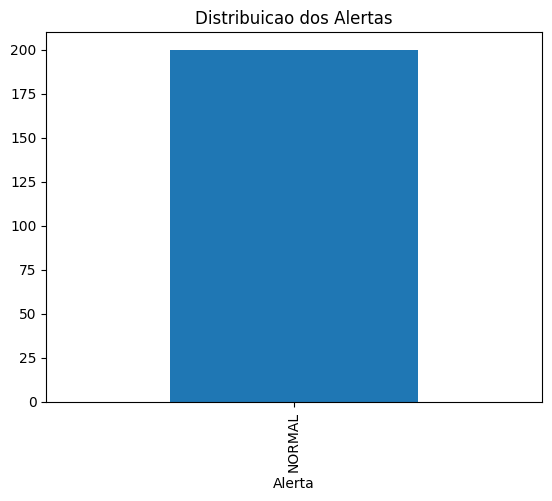

In [53]:
#DISTRIBUIÇÃO DOS ALERTAS
df["Alerta"].value_counts().plot(
kind="bar"
)

plt.title("Distribuicao dos Alertas")

plt.show()

In [54]:
#EXPORTAÇÃO DOS RESULTADOS
df.to_csv(
"dados_missao_espacial.csv",
index=False
)

print("Arquivo exportado com sucesso.")

Arquivo exportado com sucesso.
